# Part 2.3 Logistic Regression

Predict the likelihood of an employee seeking mental health treatment

/var/folders/p6/dvcp9zk51c534gxpxqw62v680000gp/T/ipykernel_40935/9739182.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['work_interfere'] = X['work_interfere'].map(work_interfere_mapping)
/var/folders/p6/dvcp9zk51c534gxpxqw62v680000gp/T/ipykernel_40935/9739182.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(X.median(), inplace=True)


Best Random Forest Parameters: {'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


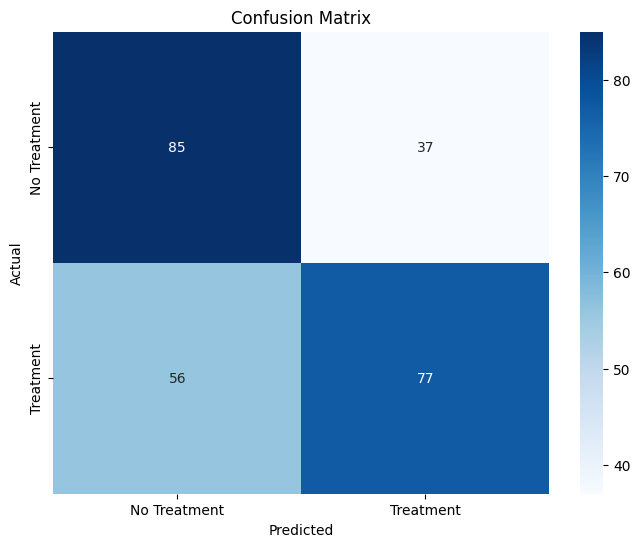

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.70      0.65       122
           1       0.68      0.58      0.62       133

    accuracy                           0.64       255
   macro avg       0.64      0.64      0.63       255
weighted avg       0.64      0.64      0.63       255

Balanced Accuracy: 0.64


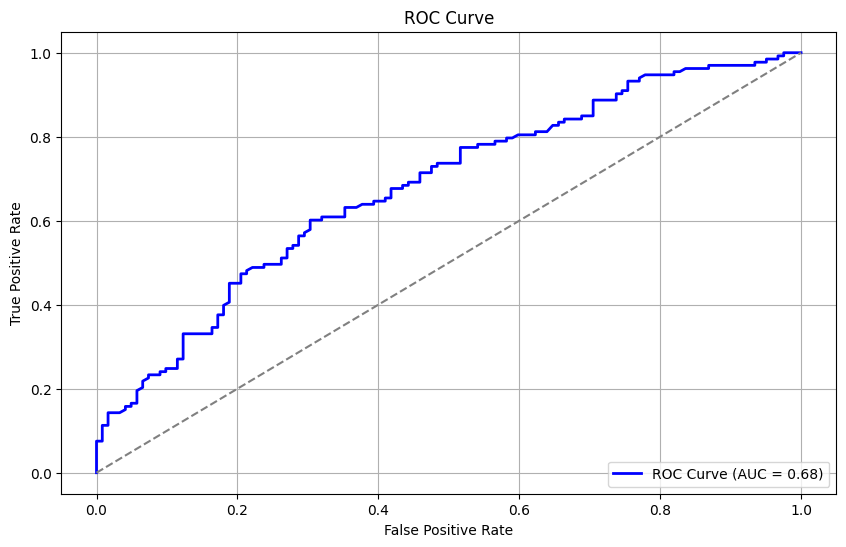

In [6]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from imblearn.over_sampling import SMOTE  # For handling class imbalance
import matplotlib.pyplot as plt
import seaborn as sns

# Load the preprocessed dataset
file_path = '/Users/luischan/Downloads/preprocessed_survey.csv'
df = pd.read_csv(file_path)

# Data Preparation

# Map 'treatment' to binary (Yes = 1, No = 0)
df['treatment'] = df['treatment'].map({'Yes': 1, 'No': 0})

# Select features and target variable
features = ['age', 'stigma_score', 'employer_support_score', 'work_interfere']
X = df[features]
y = df['treatment']

# Convert 'work_interfere' responses to numeric values
work_interfere_mapping = {
    'Never': 0,
    'Rarely': 1,
    'Sometimes': 2,
    'Often': 3
}
X['work_interfere'] = X['work_interfere'].map(work_interfere_mapping)

# Handle missing values by filling with median for numerical columns
X.fillna(X.median(), inplace=True)

# Feature Engineering: Add Polynomial Features
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X)

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

# Address Class Imbalance with SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Apply PCA for Dimensionality Reduction
pca = PCA(n_components=8)  # Adjust the number of components based on explained variance
X_pca = pca.fit_transform(X_resampled)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_resampled, test_size=0.2, random_state=42)

# Hyperparameter Tuning for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='f1')
grid_search_rf.fit(X_train, y_train)

# Best Random Forest Model
best_rf = grid_search_rf.best_estimator_
print(f"Best Random Forest Parameters: {grid_search_rf.best_params_}")

# Stacking Classifier
estimators = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('rf', best_rf),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
]
stacking_clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(max_iter=1000))
stacking_clf.fit(X_train, y_train)

# Make predictions
y_pred = stacking_clf.predict(X_test)
y_pred_prob = stacking_clf.predict_proba(X_test)[:, 1]

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Treatment', 'Treatment'], yticklabels=['No Treatment', 'Treatment'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Balanced Accuracy
balanced_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {balanced_acc:.2f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


# Conclusion 
---

## **1. Steps Taken**

1. **Data Preparation**:
   - Handled missing values and encoded categorical features.
   - Balanced classes using **SMOTE**.

2. **Feature Engineering**:
   - Added **polynomial features** for interaction terms.
   - Applied **PCA** for dimensionality reduction.

3. **Model Development**:
   - Combined **Logistic Regression**, **Random Forest**, and **Gradient Boosting** using a **Stacking Classifier**.

---

## **2. Results**

### **Confusion Matrix**

| Actual / Predicted | No Treatment | Treatment |
|---------------------|--------------|-----------|
| **No Treatment**   | 85           | 37        |
| **Treatment**       | 56           | 77        |

### **Classification Report**

| Class          | Precision | Recall | F1-Score | Support |
|----------------|-----------|--------|----------|---------|
| **No Treatment** | 0.60      | 0.70   | 0.65     | 122     |
| **Treatment**    | 0.68      | 0.58   | 0.62     | 133     |

| Metric             | Value |
|--------------------|-------|
| **Accuracy**       | 0.64  |
| **Balanced Accuracy** | 0.64  |
| **Total Support**  | 255   |


### **ROC Curve and AUC**

- **AUC = 0.68**

---

## **3. Conclusion**

- **Balanced Accuracy**: **64%**  
- The **Stacking Classifier** provided moderate performance in predicting mental health treatment.
- Results are reasonable given the complexity of the problem and dataset limitations.

**Future Improvements**:  
- Add more relevant features.  
- Explore advanced models like **XGBoost** or **LightGBM**.

